In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

2026-06-08 10:52:41.634882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780915961.919283      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780915961.998747      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780915962.636400      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780915962.636447      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780915962.636449      58 computation_placer.cc:177] computation placer alr

In [2]:
import os

print("Datasets in /kaggle/input:")
print(os.listdir('/kaggle/input'))

Datasets in /kaggle/input:
['datasets']


In [3]:
import os

for dirname, dirs, files in os.walk('/kaggle/input/datasets'):
    print(dirname)

/kaggle/input/datasets
/kaggle/input/datasets/sriramr
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshoranges
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenoranges
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshbanana
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenapples
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classi

In [4]:
#load dataset4
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Correct dataset paths (IMPORTANT)
base_path = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset"

train_dir = base_path + "/train"
test_dir = base_path + "/test"

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation + validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Test data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# TRAIN generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# VALIDATION generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# TEST generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Print dataset info
print("\nClass mapping:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.

Class mapping: {'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}
Training samples: 8723
Validation samples: 2178
Test samples: 2698


In [17]:
print("history exists:", 'history' in globals())
print("cnn exists:", 'cnn' in globals())

history exists: False
cnn exists: False


In [19]:
print("train_generator:", 'train_generator' in globals())
print("val_generator:", 'val_generator' in globals())
print("test_generator:", 'test_generator' in globals())
print("cnn:", 'cnn' in globals())
print("history:", 'history' in globals())

train_generator: False
val_generator: False
test_generator: False
cnn: False
history: False


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset"

train_dir = base_path + "/train"
test_dir = base_path + "/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

2026-06-08 15:00:33.364912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780930833.677109      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780930833.766905      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780930834.404393      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780930834.404455      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780930834.404458      58 computation_placer.cc:177] computation placer alr

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

cnn.summary()

2026-06-08 15:01:12.775684: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
print(cnn.loss)
print(cnn.optimizer)

categorical_crossentropy


In [25]:
history = cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 580s 2s/step - accuracy: 0.6661 - loss: 0.9174 - val_accuracy: 0.8802 - val_loss: 0.3610
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.8365 - loss: 0.4611 - val_accuracy: 0.8893 - val_loss: 0.2979
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.8703 - loss: 0.3799 - val_accuracy: 0.9040 - val_loss: 0.2483
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.8812 - loss: 0.3265 - val_accuracy: 0.9008 - val_loss: 0.2923
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.8940 - loss: 0.2964 - val_accuracy: 0.9265 - val_loss: 0.1838
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.9068 - loss: 0.2512 - val_accuracy: 0.8949 - val_loss: 0.2977
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.9046 - loss: 0.2643 - val_accuracy: 0.9302 - val_loss: 0.1931
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.9159 - loss: 0.2377 - val_accu

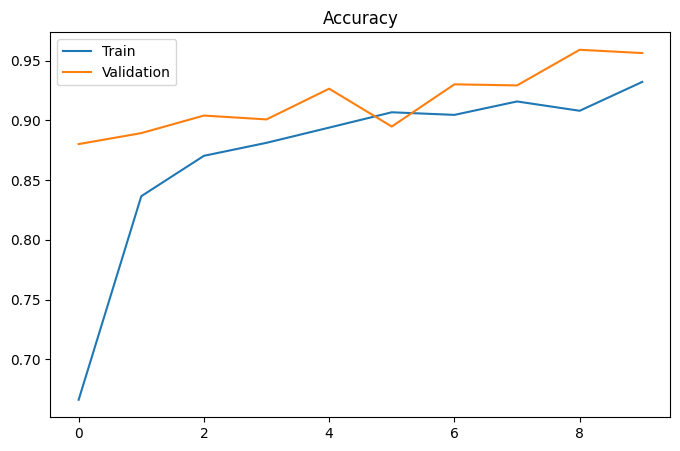

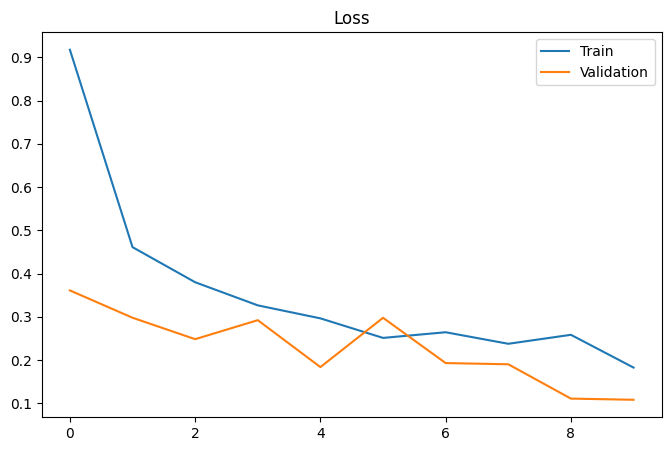

In [26]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()

85/85 ━━━━━━━━━━━━━━━━━━━━ 51s 602ms/step


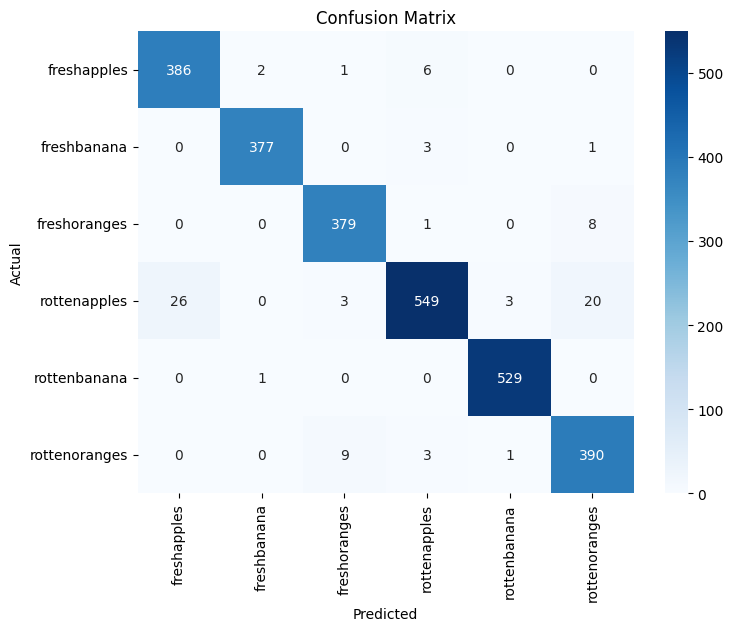

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predictions
predictions = cnn.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropoutprint('cnn exists:', 'cnn' in globals())
print('history exists:', 'history' in globals())

In [32]:
print("Notebook is running")

Notebook is running


In [36]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 created successfully")

MobileNetV2 created successfully


In [39]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(6, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

In [40]:
print(mobilenet_model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 2,388,614 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [41]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    verbose=1
)

Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 1075s 4s/step - accuracy: 0.7182 - loss: 0.8177 - val_accuracy: 0.2149 - val_loss: 1.8515
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 1025s 4s/step - accuracy: 0.8330 - loss: 0.5370 - val_accuracy: 0.2149 - val_loss: 1.9184
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 1037s 4s/step - accuracy: 0.8636 - loss: 0.4269 - val_accuracy: 0.2149 - val_loss: 1.9369
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 1006s 4s/step - accuracy: 0.8802 - loss: 0.3712 - val_accuracy: 0.2149 - val_loss: 1.9060
Epoch 5/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 1012s 4s/step - accuracy: 0.8870 - loss: 0.3490 - val_accuracy: 0.2149 - val_loss: 1.8596


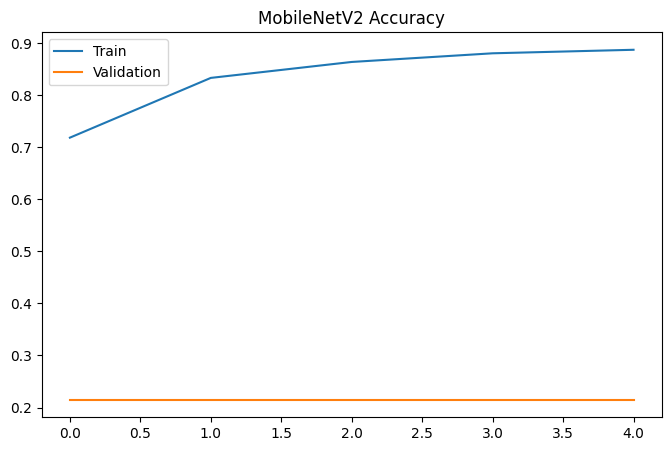

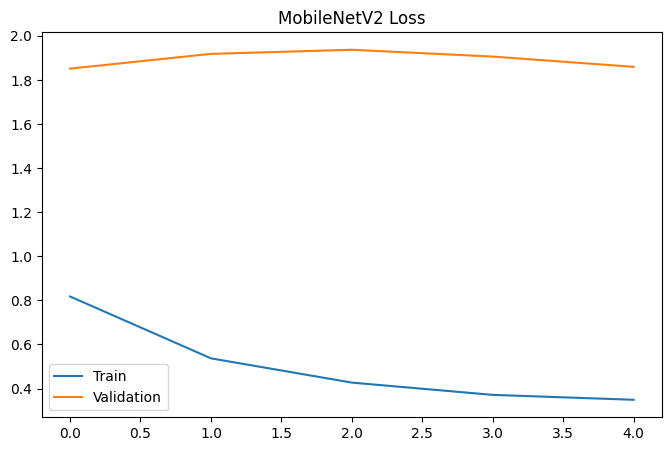

In [43]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title("MobileNetV2 Accuracy")
plt.legend(['Train','Validation'])
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title("MobileNetV2 Loss")
plt.legend(['Train','Validation'])
plt.show()

In [44]:
import numpy as np

pred = mobilenet_model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

85/85 ━━━━━━━━━━━━━━━━━━━━ 57s 646ms/step


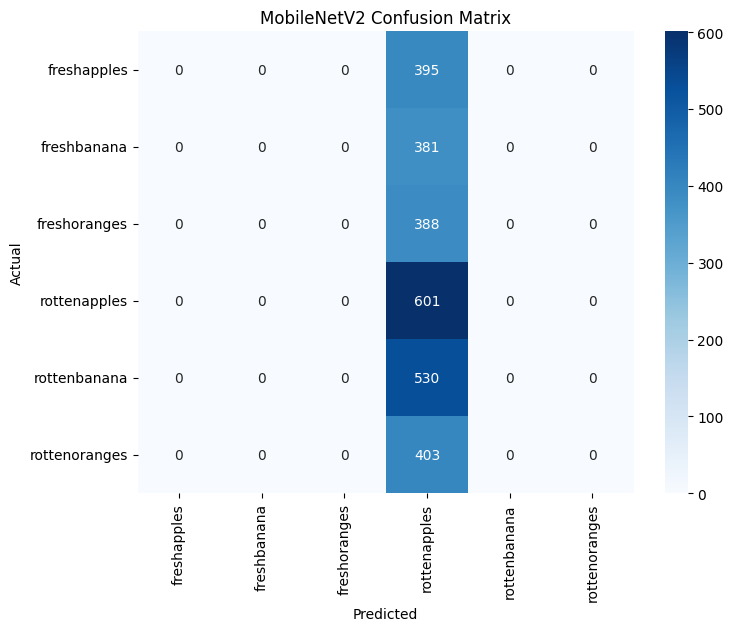

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    )
)

               precision    recall  f1-score   support

  freshapples       0.00      0.00      0.00       395
  freshbanana       0.00      0.00      0.00       381
 freshoranges       0.00      0.00      0.00       388
 rottenapples       0.22      1.00      0.36       601
 rottenbanana       0.00      0.00      0.00       530
rottenoranges       0.00      0.00      0.00       403

     accuracy                           0.22      2698
    macro avg       0.04      0.17      0.06      2698
 weighted avg       0.05      0.22      0.08      2698



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
mobilenet_model.save("mobilenet_fruit_model.keras")

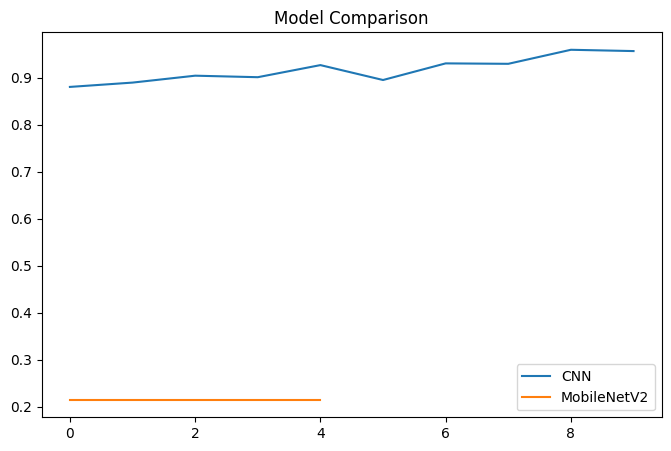

In [48]:
plt.figure(figsize=(8,5))

plt.plot(history.history['val_accuracy'], label='CNN')
plt.plot(history_mobilenet.history['val_accuracy'], label='MobileNetV2')

plt.title("Model Comparison")
plt.legend()
plt.show()

In [49]:
cnn_train_acc = history.history['accuracy'][-1]
cnn_val_acc = history.history['val_accuracy'][-1]

mobilenet_train_acc = history_mobilenet.history['accuracy'][-1]
mobilenet_val_acc = history_mobilenet.history['val_accuracy'][-1]

print(cnn_train_acc, cnn_val_acc)
print(mobilenet_train_acc, mobilenet_val_acc)

0.932248055934906 0.9563819766044617
0.8869655132293701 0.21487602591514587


In [50]:
import pandas as pd

data = {
    "Model": ["CNN", "MobileNetV2"],
    "Train Accuracy": [
        cnn_train_acc,
        mobilenet_train_acc
    ],
    "Validation Accuracy": [
        cnn_val_acc,
        mobilenet_val_acc
    ]
}

df = pd.DataFrame(data)
df

,Model,Train Accuracy,Validation Accuracy
0,CNN,0.932248,0.956382
1,MobileNetV2,0.886966,0.214876


In [51]:
df.style.format({
    "Train Accuracy": "{:.4f}",
    "Validation Accuracy": "{:.4f}"
})

,Model,Train Accuracy,Validation Accuracy
0,CNN,0.9322,0.9564
1,MobileNetV2,0.8870,0.2149


In [52]:
cnn_test_loss, cnn_test_acc = cnn.evaluate(test_generator)

mobilenet_test_loss, mobilenet_test_acc = mobilenet_model.evaluate(test_generator)

extra = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2"],
    "Test Accuracy": [cnn_test_acc, mobilenet_test_acc]
})

extra

85/85 ━━━━━━━━━━━━━━━━━━━━ 41s 481ms/step - accuracy: 0.9674 - loss: 0.0979
85/85 ━━━━━━━━━━━━━━━━━━━━ 52s 606ms/step - accuracy: 0.2228 - loss: 1.8493


,Model,Test Accuracy
0,CNN,0.967383
1,MobileNetV2,0.222758
